**Introduction:**

In the ongoing battle against cyberbullying, this code represents a robust arsenal, employing advanced techniques and models to analyze and model cyberbullying data. By amalgamating cutting-edge natural language processing methods and machine learning algorithms, the code delves into the intricate layers of online interactions to foster a deeper understanding of cyberbullying dynamics.

**Process Overview:**

1. **Data Loading:**
   - Mounting Google Drive and accessing a JSON dataset.
   - Transformation of raw data into a Pandas DataFrame.

2. **Label Extraction:**
   - Extraction of labels from the 'annotation' column.
   - Organizing extracted labels into a list.

3. **Hybrid Word Embeddings:**
   - Utilising **FastText and BERT** for generating hybrid word embeddings.
   - Saving embeddings in NumPy **(.npy)** file format.

4. **Autoencoder for Dimensionality Reduction:**
   - Definition and training of an **autoencoder neural network**.
   - Dimensionality reduction to 32 using mean squared error as the loss function.

5. **Visualization with t-SNE:**
   - Visualizing encoded features with t-Distributed Stochastic Neighbor Embedding **(t-SNE)**.
   - Creation of a scatter plot with color-coded labels using Plotly.

6. **Temporal Convolutional Network (TCN):**
   - Integration of TCN library for cyberbullying classification.
   - Input features derived from t-SNE-transformed embeddings.
   - Data split into training and testing sets with an 80-20 ratio.

7. **Model Training:**
   - Training the **TCN model** with the addition of a temporal dimension.
   - Compilation with the Adam optimizer and categorical cross-entropy loss.
   - Further predictions are made using **ExtraTrees Classifier** with the help of trained features by TCN, making a complete model as hybrid model.

**Techniques and Models Employed:**
- Pandas for efficient data manipulation and organisation.
- FastText and BERT for generating hybrid word embeddings.
- Autoencoder neural network for dimensionality reduction.
- t-Distributed Stochastic Neighbor Embedding (t-SNE) for visualisation.
- Temporal Convolutional Network (TCN) for cyberbullying classification.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Python Libraries and Modules

In [4]:
!pip install keras-tcn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 12.0 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.2
    Uninstalling typeguard-4.4.2:
      Successfully uninstalled typeguard-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [5]:
!pip install tensorflow==2.12.0

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 5.9 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstal

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV
import tensorflow as tf
from tcn import TCN
from sklearn.ensemble import ExtraTreesClassifier
from tensorflow.keras.layers import Input, Dense, concatenate, Reshape, BatchNormalization, Dropout, Flatten
from tensorflow.keras.models import Model
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, roc_curve, auc, classification_report, log_loss, roc_auc_score, ConfusionMatrixDisplay

### **DATA LOADING**

In [2]:
cyber_data = pd.read_json('Dataset for Detection of Cyber-Trolls (2).json', lines=True)
cyber_data.head(4)

,content,annotation,extras
0,Get fucking real dude.,"{'notes': '', 'label': ['1']}",NaN
1,She is as dirty as they come and that crook ...,"{'notes': '', 'label': ['1']}",NaN
2,why did you fuck it up. I could do it all day...,"{'notes': '', 'label': ['1']}",NaN
3,Dude they dont finish enclosing the fucking s...,"{'notes': '', 'label': ['1']}",NaN


#### General Data Information

In [3]:
cyber_data.shape

(20001, 3)

The given format **(20001, 3)** typically represents a tuple, where the first value **(20001)** signifies the number of rows or observations in a dataset, and the second value **(3)** indicates the number of columns or features present in each observation.

In this specific context, it suggests that the dataset consists of **20,001** data points, with each data point containing **3** distinct features.

In [4]:
labels = []
for row in cyber_data.annotation:
  labels.append(int(row['label'][0]))

print("Total number of Target Labels: ", len(labels))

Total number of Target Labels:  20001


In [ ]:
from collections import Counter
Counter(labels)

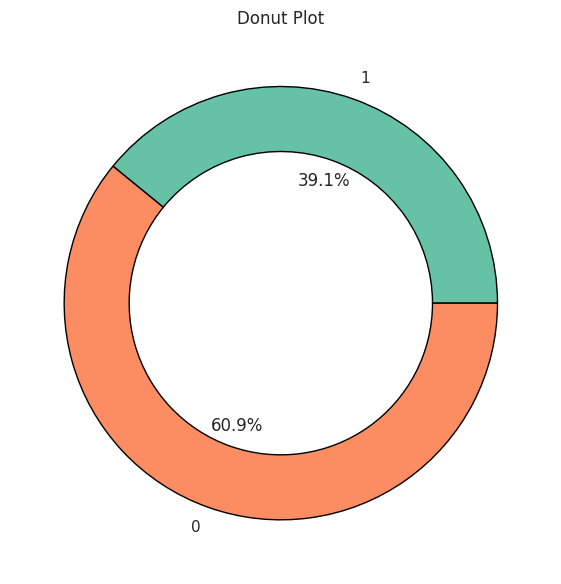

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

class_distribution = Counter({1: 7822, 0: 12179})
df = pd.DataFrame({'Labels': list(class_distribution.keys()), 'Count': list(class_distribution.values())})

sns.set(style="whitegrid")
colors = sns.color_palette("Set2")

fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(df['Count'], labels=df['Labels'], autopct='%1.1f%%', colors=colors, wedgeprops=dict(width=0.3, edgecolor='black'))
ax.set_title('Donut Plot')

total_count = df['Count'].sum()
for i, label in enumerate(df['Labels']):
    count = df['Count'][i]
    percentage = (count / total_count) * 100
    ax.text(0, 0, f"{count}\n{percentage:.1f}%", ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

The class distribution plots reveal a little imbalance in the dataset, with Class 0 having a significantly higher count (12,179) compared to Class 1 (7,822).


### **Content Analysis**

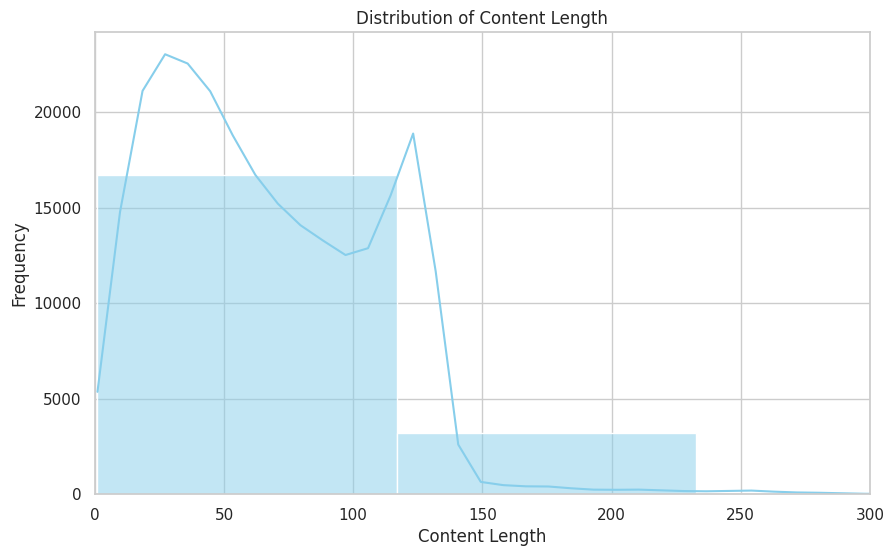

In [15]:
# Distribution of the 'content' length
cyber_data['content_length'] = cyber_data['content'].apply(len)
plt.figure(figsize=(10, 6))
# Limit x-axis to 300
sns.histplot(cyber_data['content_length'], bins=15, kde=True, color='skyblue')
plt.title('Distribution of Content Length')
plt.xlabel('Content Length')
plt.ylabel('Frequency')
# Set x-axis limit to 300
plt.xlim(0, 300)
plt.show()

Content length is mostly left skewed. Mostly the comments are short in length with a range of 10-200

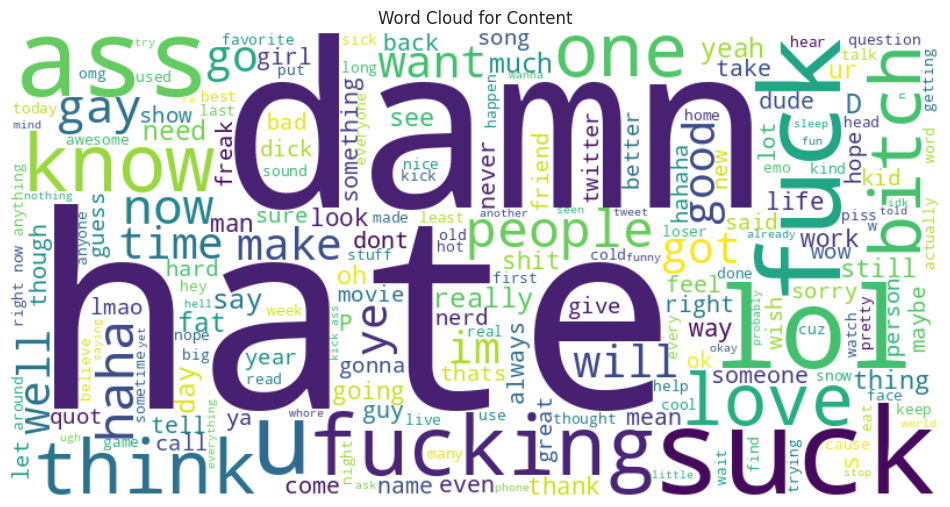

In [13]:
from wordcloud import WordCloud

all_text = ' '.join(cyber_data['content'])
wordcloud = WordCloud(width=800, height=400, random_state=42, background_color='white').generate(all_text)
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Content')
plt.show()

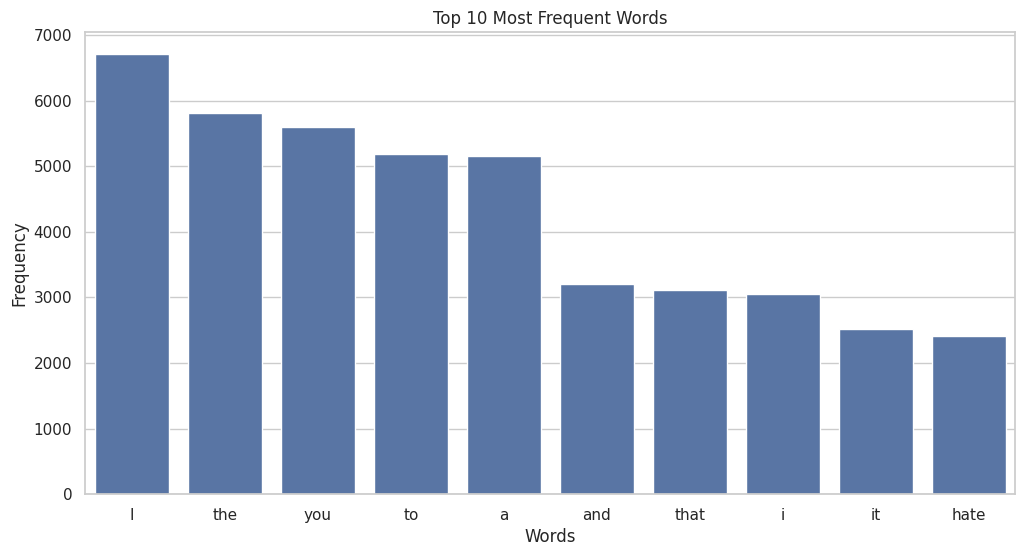

In [8]:
# Tokenize words
words = ' '.join(cyber_data['content']).split()

# Count word frequencies
word_counts = Counter(words)

# Plot the top N frequent words
top_words = word_counts.most_common(10)  # Change 10 to your desired number
plt.figure(figsize=(12, 6))
sns.barplot(x=[word[0] for word in top_words], y=[word[1] for word in top_words])
plt.title('Top 10 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

Since these frequent words do not serve as essential information about the data, these can be removed while makin embeddings. In bert, such stopwords are removed using inbuilt preprocessing commands along with punctuations and other unnecessary characters.

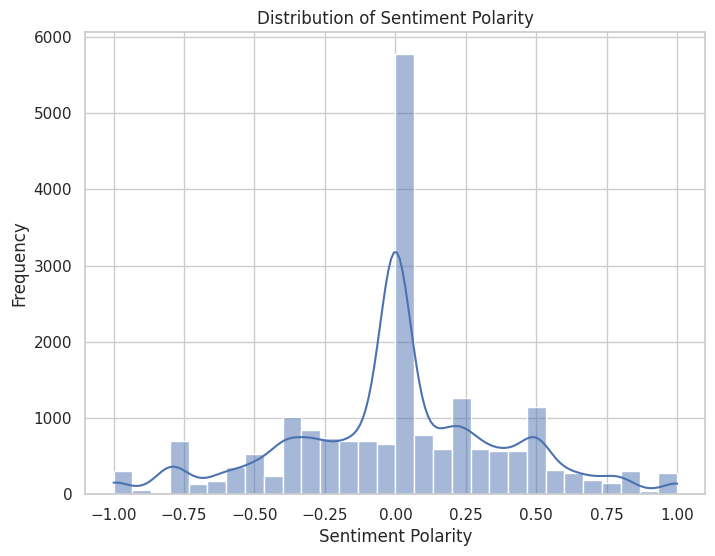

In [9]:
from textblob import TextBlob

# Compute sentiment polarity for each content
cyber_data['sentiment'] = cyber_data['content'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Plot the distribution of sentiment
plt.figure(figsize=(8, 6))
sns.histplot(cyber_data['sentiment'], bins=30, kde=True)
plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Frequency')
plt.show()


- Comments exhibit a normal distribution in sentiment polarity.
- Predominantly neutral tones, fostering a balanced and harmonious online environment.
- Equal numbers in negative and positive sentiments indicate measured opinions.
- Opportunities for diverse engagement strategies.

### **Load hybrid Embedding (Fasttext + BERT)**

What's been done:
Using fasttext and bert, hybrid word embeddings have been made and save to npy file format in cyber_bullying.ipynb.

To continue the work, load embedding from the saved folder.

In [10]:
embedding_path = '/content/drive/MyDrive/project/data_main/hybrid_embedding_array.npy'
hybrid_embeddings = np.load(embedding_path)
hybrid_embeddings.shape

(20001, 1, 1068)

### **Feature Extraction - Autoencoders**

In [41]:
# Reshape the embeddings to (20001, 1068)
hybrid_embeddings = hybrid_embeddings.reshape(20001, 1068)

# Define the autoencoder model
input_dim = hybrid_embeddings.shape[1]
encoding_dim = 32

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Train the autoencoder
autoencoder_model = autoencoder.fit(hybrid_embeddings, hybrid_embeddings, epochs=6, batch_size=1, shuffle=True)

encoder_model = Model(input_layer, encoded)
encoded_features_autoencoder = encoder_model.predict(hybrid_embeddings)

Epoch 1/6
20001/20001 [==============================] - 49s 2ms/step - loss: 0.0588
Epoch 2/6
20001/20001 [==============================] - 42s 2ms/step - loss: 0.0575
Epoch 3/6
20001/20001 [==============================] - 43s 2ms/step - loss: 0.0575
Epoch 4/6
20001/20001 [==============================] - 42s 2ms/step - loss: 0.0574
Epoch 5/6
20001/20001 [==============================] - 42s 2ms/step - loss: 0.0574
Epoch 6/6
626/626 [==============================] - 1s 1ms/step


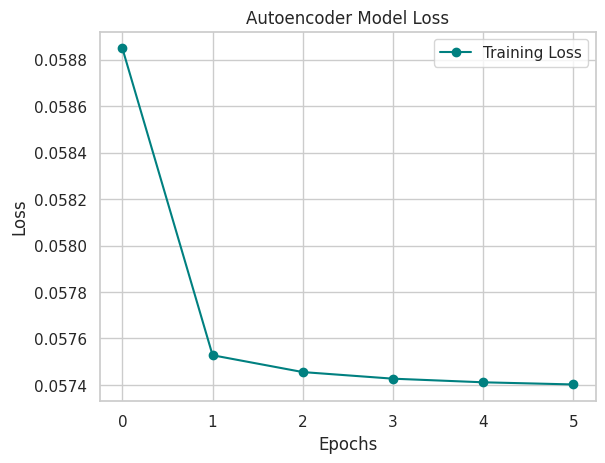

In [42]:
# Autoencoder loss during feature extraction

history = autoencoder_model.history

# Plot loss with blue markers and orange line
plt.plot(history['loss'], 'o-', color='teal', label='Training Loss')

# Customize the plot
plt.title('Autoencoder Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

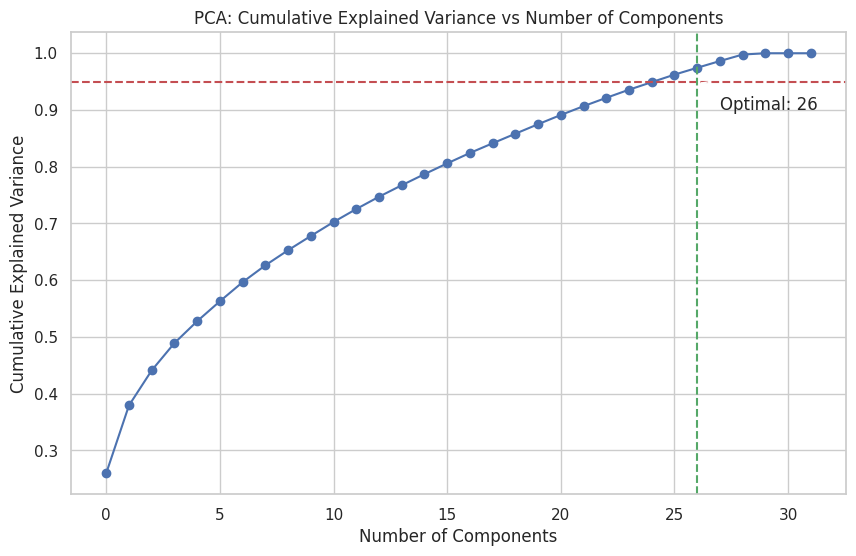

Optimal number of PCA components: 26
Reduced feature shape: (20001, 26)
Total variance explained: 96.23%


In [17]:
from sklearn.decomposition import PCA

def find_optimal_components(data, variance_threshold=0.95):
    """Find the optimal number of PCA components that explain the given variance threshold"""
    pca = PCA()
    pca.fit(data)

    # Plot the explained variance
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_variance, marker='o')
    plt.axhline(y=variance_threshold, color='r', linestyle='--')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('PCA: Cumulative Explained Variance vs Number of Components')
    plt.grid(True)

    # Find optimal components
    optimal_components = np.where(cumulative_variance >= variance_threshold)[0][0] + 1
    plt.axvline(x=optimal_components, color='g', linestyle='--')
    plt.annotate(f'Optimal: {optimal_components}',
                xy=(optimal_components, variance_threshold),
                xytext=(optimal_components+1, variance_threshold-0.05),
                arrowprops=dict(arrowstyle='->'))

    plt.show()
    return optimal_components

optimal_components = find_optimal_components(encoded_features_autoencoder)
print(f"Optimal number of PCA components: {optimal_components}")

pca = PCA(n_components=optimal_components)
reduced_features = pca.fit_transform(encoded_features_autoencoder)
print(f"Reduced feature shape: {reduced_features.shape}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

### **Data Splitting to Train & Test Sets**

In [18]:
from sklearn.model_selection import train_test_split
labels = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(
    reduced_features, labels, test_size=0.2, random_state=42, stratify=labels
)


In [19]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16000, 26)
y_train shape: (16000,)
X_test shape: (4001, 26)
y_test shape: (4001,)


In [20]:
X_test.shape

(4001, 26)

### **Model Building- Random Forest**

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

In [22]:
# Reshape the data
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)


rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]


loss: 0.36739868990357827
AUC: 0.9656691166055493
Accuracy: 0.8898
F1 Score: 0.8699
Recall: 0.9425

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.86      0.90      2436
           1       0.81      0.94      0.87      1565

    accuracy                           0.89      4001
   macro avg       0.88      0.90      0.89      4001
weighted avg       0.90      0.89      0.89      4001



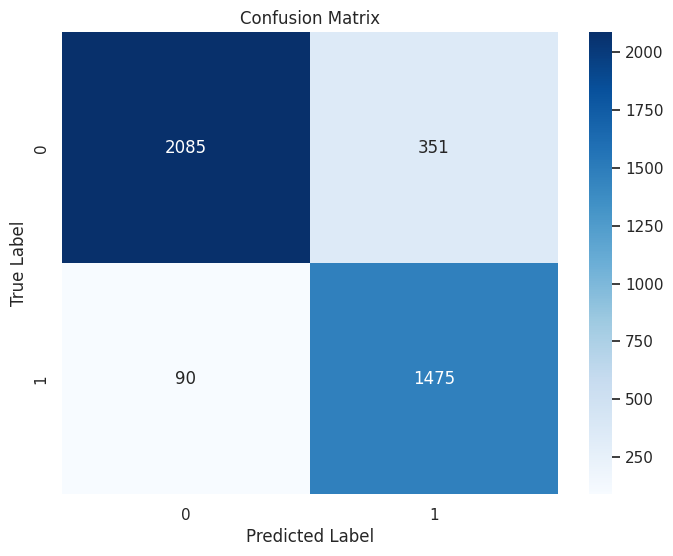

In [23]:
logloss = log_loss(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)


from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print("loss:", logloss)
print("AUC:", roc_auc)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

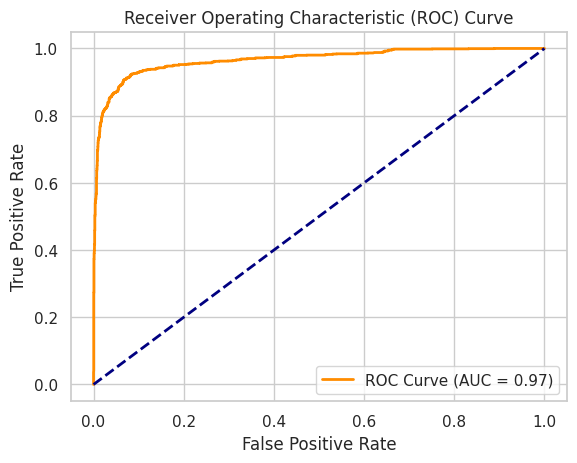

In [24]:
# ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

### **Model Building & Feature Tuning - TCN**


In [30]:
def build_simplified_model(input_shape):
    from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, MaxPooling1D, Dropout, GlobalAveragePooling1D, Dense, Reshape  # Import necessary layers
    input_layer = Input(shape=input_shape)

    # Reshape to add a temporal dimension
    reshaped_input = Reshape((input_shape[0], 1))(input_layer)  # Reshape to (26, 1)

    # Simpler convolutional layers appropriate for 2D input
    conv1 = Conv1D(filters=64, kernel_size=3, padding='same', activation='relu')(reshaped_input)  # Use reshaped_input
    bn1 = BatchNormalization()(conv1)
    pool1 = MaxPooling1D(pool_size=2)(bn1)
    drop1 = Dropout(0.2)(pool1)

    conv2 = Conv1D(filters=32, kernel_size=3, padding='same', activation='relu')(drop1)
    bn2 = BatchNormalization()(conv2)
    pool2 = MaxPooling1D(pool_size=2)(bn2)
    drop2 = Dropout(0.2)(pool2)

    # Global pooling layer
    gap = GlobalAveragePooling1D()(drop2)

    # Dense layers
    dense = Dense(32, activation='relu')(gap)
    output_layer = Dense(1, activation='sigmoid')(dense)

    # Create and compile the model
    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Create an intermediate model for feature extraction
    intermediate_model = Model(inputs=input_layer, outputs=dense)

    return model, intermediate_model

# Build and train the simplified model
input_shape = reduced_features.shape[1:]
simplified_model, intermediate_model = build_simplified_model(input_shape)

# Use the intermediate model to get features
features_train = intermediate_model.predict(X_train)
features_test = intermediate_model.predict(X_test)

126/126 [==============================] - 0s 3ms/step


In [33]:
simplified_model.summary()

Model: "model_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 26)]              0         
                                                                 
 reshape_3 (Reshape)         (None, 26, 1)             0         
                                                                 
 conv1d_5 (Conv1D)           (None, 26, 64)            256       
                                                                 
 batch_normalization_5 (Batc  (None, 26, 64)           256       
 hNormalization)                                                 
                                                                 
 max_pooling1d_4 (MaxPooling  (None, 13, 64)           0         
 1D)                                                             
                                                                 
 dropout_5 (Dropout)         (None, 13, 64)            0   

In [34]:
history = simplified_model.fit(X_train_reshaped, y_train, epochs=100, batch_size=64, validation_split=0.2)

Epoch 1/100
200/200 [==============================] - 8s 21ms/step - loss: 0.6484 - accuracy: 0.6062 - val_loss: 0.6642 - val_accuracy: 0.6169
Epoch 2/100
200/200 [==============================] - 6s 29ms/step - loss: 0.6223 - accuracy: 0.6240 - val_loss: 0.6179 - val_accuracy: 0.6344
Epoch 3/100
200/200 [==============================] - 4s 21ms/step - loss: 0.6148 - accuracy: 0.6308 - val_loss: 0.5963 - val_accuracy: 0.6569
Epoch 4/100
200/200 [==============================] - 4s 19ms/step - loss: 0.6095 - accuracy: 0.6339 - val_loss: 0.5862 - val_accuracy: 0.6675
Epoch 5/100
200/200 [==============================] - 4s 22ms/step - loss: 0.6070 - accuracy: 0.6434 - val_loss: 0.5799 - val_accuracy: 0.6772
Epoch 6/100
200/200 [==============================] - 3s 17ms/step - loss: 0.6039 - accuracy: 0.6419 - val_loss: 0.5791 - val_accuracy: 0.6694
Epoch 7/100
200/200 [==============================] - 2s 12ms/step - loss: 0.5972 - accuracy: 0.6429 - val_loss: 0.5823 - val_accuracy:

In [35]:
loss, accuracy = simplified_model.evaluate(X_test_reshaped, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

126/126 [==============================] - 1s 2ms/step - loss: 0.5390 - accuracy: 0.6981
Test Loss: 0.5390486717224121
Test Accuracy: 0.6980754733085632


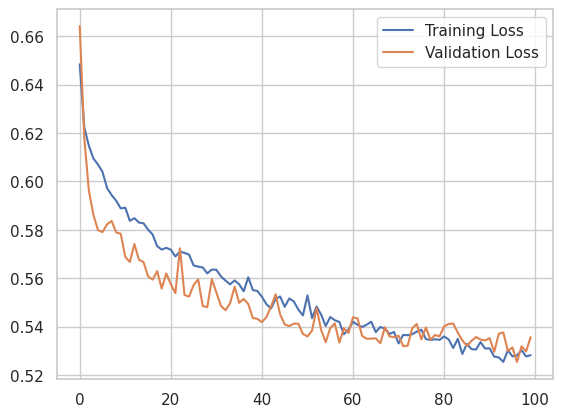

In [36]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

### **ExtraTrees Classifier for Training & Prediction**

The above neural network is followed by a machine learning classification model, an ensemble technique based classifier. The features are fined tuned using the TCN network and the trained using the classifc ensemble trees based classfiier. This results in less complex training because of dimenionally reduced features that holds essential patterns.

In [37]:
# Create Extra Trees Classifier
et_classifier = ExtraTreesClassifier(random_state=42)

# Define parameter grid for tuning
param_grid = {
    'n_estimators': [10, 20, 30],
    'max_depth': [None, 5, 10, 15],
}

# Define scoring metric
scorer = make_scorer(accuracy_score)

# Perform Grid Search Cross Validation
grid_search = GridSearchCV(et_classifier, param_grid, scoring=scorer, cv=5)
grid_search.fit(features_train, y_train)

# Print the best parameters
print("Best Parameters:", grid_search.best_params_)

# Get the best model
best_et_classifier = grid_search.best_estimator_

# Predict on the test set using the best model
y_pred = best_et_classifier.predict(features_test)

# Evaluate accuracy on the test set
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Best Parameters: {'max_depth': None, 'n_estimators': 30}
Accuracy: 0.9622594351412147


### **Results and Evaluation**

In [38]:
# Evaluate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Evaluate other metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
logloss = log_loss(y_test, y_pred)

# Print other metrics
print("Model F1 Score:", f1)
print("Model Recall:", recall)
print("Model Log Loss:", logloss)

Accuracy: 0.9622594351412147
Model F1 Score: 0.9502798814619691
Model Recall: 0.9220447284345048
Model Log Loss: 1.3603078384795528


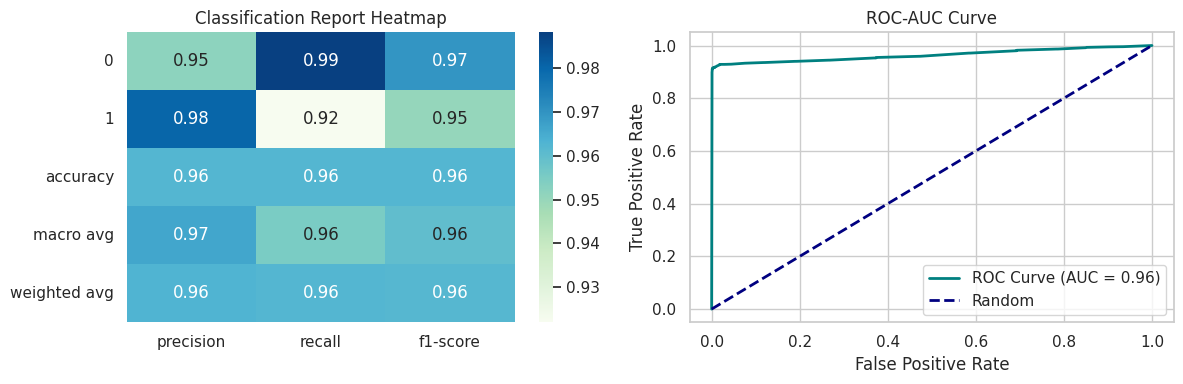

In [39]:
# Classification Report Heatmap
class_names = np.unique(y_test)
report = classification_report(y_test, y_pred, target_names=[str(class_name) for class_name in class_names], output_dict=True)

plt.figure(figsize=(12, 4))

# Subplot 1: Classification Report Heatmap
plt.subplot(1, 2, 1)
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap="GnBu", edgecolor='black')
plt.title('Classification Report Heatmap')

# Subplot 2: ROC-AUC Curves
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, best_et_classifier.predict_proba(features_test)[:, 1])
plt.plot(fpr, tpr, color='teal', lw=2, label='ROC Curve (AUC = {:.2f})'.format(auc(fpr, tpr)))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()


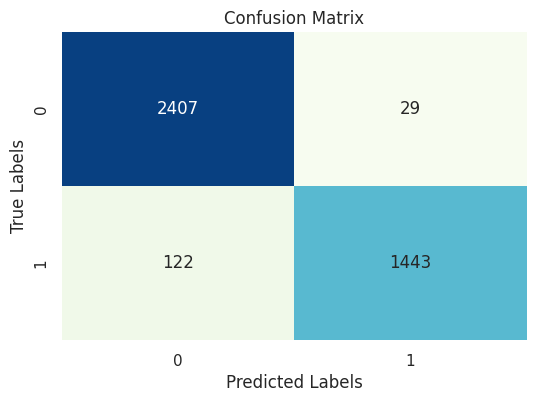

In [40]:
# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="GnBu", cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


1. **Accuracy: 96.2**
   - The accuracy of the model is approximately 96.2%. This metric represents the proportion of correctly classified instances out of the total instances in the test set.

2. **Model F1 Score: 95**
   - The F1 score is 95, which is a harmonic mean of precision and recall. It provides a balanced measure of the model's performance, considering both false positives and false negatives. A higher F1 score indicates better overall performance.

3. **Model Recall: 92**
   - The recall of the model is approximately 92%. Also known as sensitivity or true positive rate, recall measures the proportion of actual positive instances correctly identified by the model. A high recall indicates that the model is effective at capturing positive instances.

4. **Model Log Loss: 1.36**
   - The log loss is 1.36. It quantifies the performance of a classification model by penalizing false classifications. Lower log loss values are preferable, and the actual interpretation may vary based on the specific problem domain.

